# SVR for AOR Prediction - Jupyter Notebook

In [51]:
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt
from sklearn.model_selection import GridSearchCV

In [3]:
# Import the function from the external file
from data.extract_data import extract_sections_by_elements, combine_elements_data

%load_ext autoreload
%autoreload 2

In [4]:
# Call the function to extract sections by element
elements_data = extract_sections_by_elements()

# # Access the data for 'Paracetamol' and 'SingleF'
# paracetamol_singlef_data = elements_data['SingleF']['Paracetamol']
# print(paracetamol_singlef_data)

In [5]:
# Call the function to combine data
combined_data = combine_elements_data(elements_data)

In [6]:
# X=singlef_paracetamol_data[['A:p-p fc', 'B:p-p se', 'C:p-p cr', 'D:p-w fc', 'E:p-w se', 'F:p-w cr', 'G:rr']]
X=combined_data[['A', 'B', 'C', 'D', 'E', 'F', 'G']]
y=combined_data['AOR']

In [7]:
X

,A,B,C,D,E,F,G
0,0.2,0.000050,0.400,0.28,4.000000e-07,0.3,0.600
1,0.3,0.000050,0.400,0.28,4.000000e-07,0.3,0.600
2,0.4,0.000050,0.400,0.28,4.000000e-07,0.3,0.600
3,0.5,0.000050,0.400,0.28,4.000000e-07,0.3,0.600
4,0.6,0.000050,0.400,0.28,4.000000e-07,0.3,0.600
...,...,...,...,...,...,...,...
350,0.2,0.000008,0.200,0.30,5.000000e-08,0.3,0.700
351,0.2,0.000010,0.200,0.30,5.000000e-08,0.3,0.600
352,0.2,0.000010,0.135,0.30,5.000000e-08,0.3,0.669
353,0.2,0.000010,0.113,0.30,5.000000e-08,0.3,0.648


In [8]:
y

0      40.2500
1      42.3050
2      43.6800
3      43.6050
4      43.2150
        ...   
350    34.0975
351    34.2800
352    35.6400
353    35.1900
354    34.5525
Name: AOR, Length: 355, dtype: float64

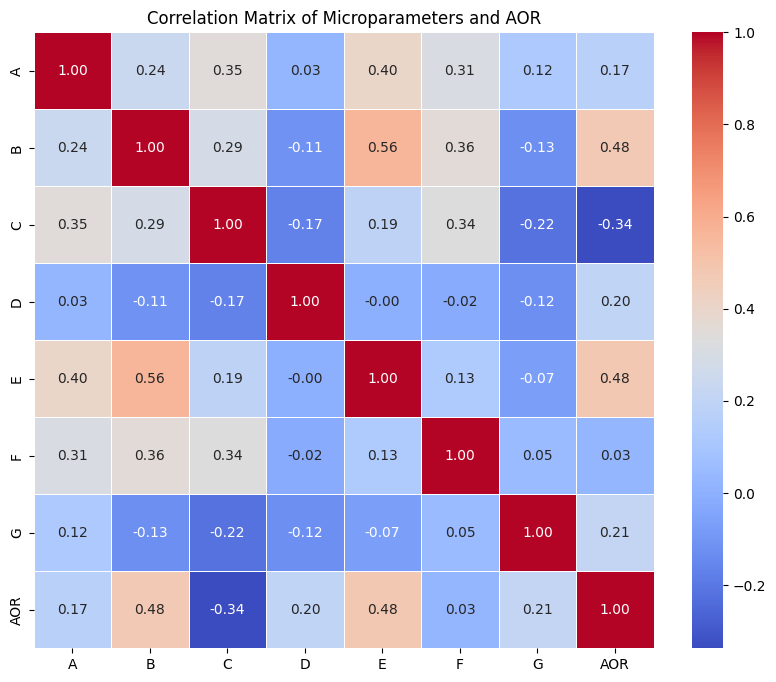

Correlations with AOR:
 AOR    1.000000
E      0.482541
B      0.475126
G      0.212471
D      0.197565
A      0.166894
F      0.025573
C     -0.337008
Name: AOR, dtype: float64


In [9]:
# Compute the correlation matrix
corr_matrix = combined_data.corr()

# Visualize the correlation matrix using Seaborn heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Matrix of Microparameters and AOR")
plt.show()

# Focus on AOR correlations
print("Correlations with AOR:\n", corr_matrix["AOR"].sort_values(ascending=False))

In [52]:
# Split the data into training and testing sets (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Normalize the features
scaler = StandardScaler()

# Fit the scaler only on the training data, then transform both train and test data
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [11]:
# Initialize the SVR model with an RBF kernel
svr_model = SVR(kernel='rbf')

# Fit the model to the training data
svr_model.fit(X_train_scaled, y_train)

# Use the trained model to predict the AOR for the test set
y_pred = svr_model.predict(X_test_scaled)

# Calculate performance metrics
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error (MSE): {mse}")
print(f"Mean Absolute Error (MAE): {mae}")
print(f"R-Squared (R2 Score): {r2}")

Mean Squared Error (MSE): 5.145588313653572
Mean Absolute Error (MAE): 1.5514620371564423
R-Squared (R2 Score): 0.8173403934602618


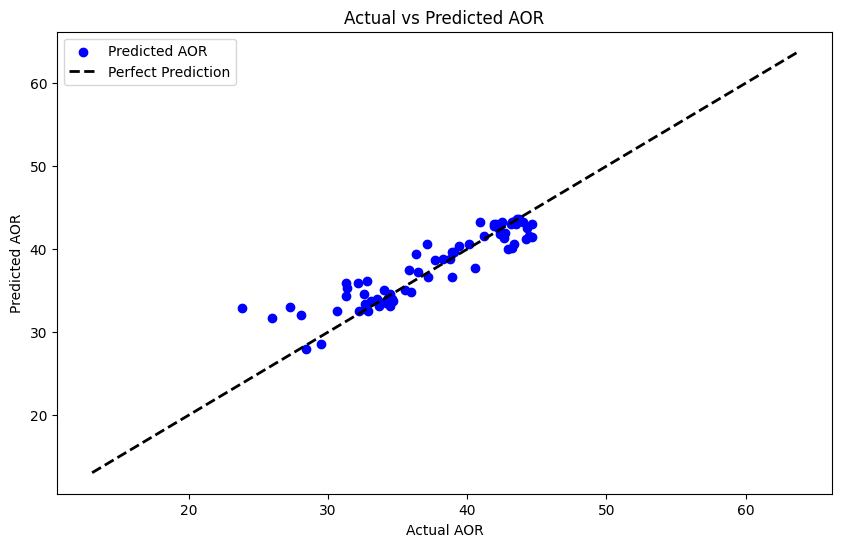

Fitting 5 folds for each of 24 candidates, totalling 120 fits
Best Parameters from GridSearch: {'C': 10, 'gamma': 'auto', 'kernel': 'rbf'}
Optimized Mean Squared Error (MSE): 2.69364437264161
Optimized Mean Absolute Error (MAE): 1.1831110602100234
Optimized R-Squared (R2 Score): 0.9043802202443703


In [12]:
# Plot the actual vs predicted values
plt.figure(figsize=(10,6))
plt.scatter(y_test, y_pred, color='blue', label='Predicted AOR')
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'k--', lw=2, label='Perfect Prediction')
plt.xlabel('Actual AOR')
plt.ylabel('Predicted AOR')
plt.title('Actual vs Predicted AOR')
plt.legend()
plt.show()

# Define the parameter grid for SVR
param_grid = {
    'C': [0.1, 1, 10, 100],  # Regularization parameter
    'gamma': ['scale', 'auto'],  # Kernel coefficient
    'kernel': ['rbf', 'linear', 'poly']  # Different kernels to test
}

# Initialize GridSearchCV
grid_search = GridSearchCV(SVR(), param_grid, cv=5, scoring='neg_mean_squared_error', verbose=2, n_jobs=-1)

# Fit GridSearchCV to the training data
grid_search.fit(X_train_scaled, y_train)

# Display the best parameters from GridSearch
print("Best Parameters from GridSearch:", grid_search.best_params_)

# Re-train the model with the best parameters
best_svr_model = grid_search.best_estimator_
best_svr_model.fit(X_train_scaled, y_train)

# Make new predictions with the optimized model
y_pred_best = best_svr_model.predict(X_test_scaled)

# Evaluate the optimized model
mse_best = mean_squared_error(y_test, y_pred_best)
mae_best = mean_absolute_error(y_test, y_pred_best)
r2_best = r2_score(y_test, y_pred_best)

print(f"Optimized Mean Squared Error (MSE): {mse_best}")
print(f"Optimized Mean Absolute Error (MAE): {mae_best}")
print(f"Optimized R-Squared (R2 Score): {r2_best}")

Mean Squared Error (MSE): 4.781813980092939
Mean Absolute Error (MAE): 1.4799224837538725
R-Squared (R2 Score): 0.830253761687006


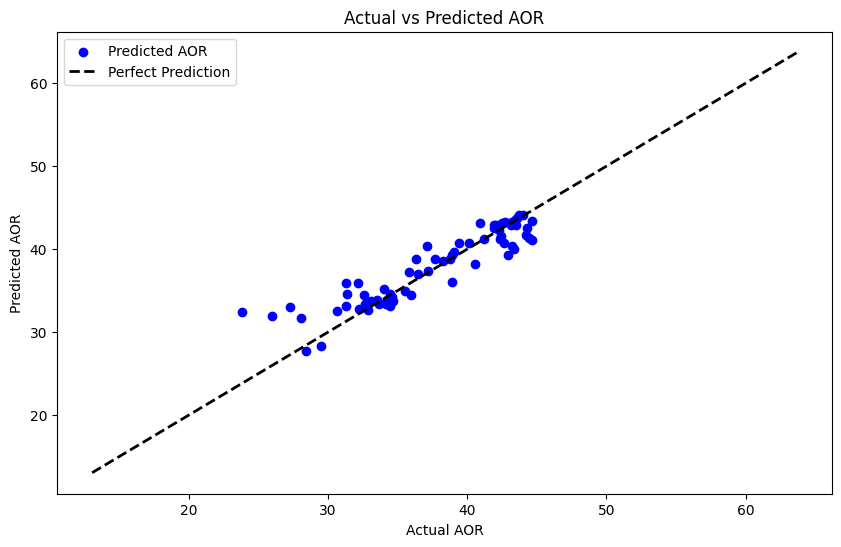

Fitting 5 folds for each of 4 candidates, totalling 20 fits
Best Parameters from GridSearch: {'C': 35.6, 'epsilon': 0.0001, 'gamma': 'auto', 'kernel': 'rbf'}
Optimized Mean Squared Error (MSE): 2.216720671784019
Optimized Mean Absolute Error (MAE): 1.0692717356446069
Optimized R-Squared (R2 Score): 0.9213101979724697


In [81]:
X=combined_data[['A', 'B', 'C', 'D', 'E', 'G']]
y=combined_data['AOR']

# Split the data into training and testing sets (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Normalize the features
scaler = StandardScaler()

# Fit the scaler only on the training data, then transform both train and test data
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Initialize the SVR model with an RBF kernel
svr_model = SVR(kernel='rbf')

# Fit the model to the training data
svr_model.fit(X_train_scaled, y_train)

# Use the trained model to predict the AOR for the test set
y_pred = svr_model.predict(X_test_scaled)

# Calculate performance metrics
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error (MSE): {mse}")
print(f"Mean Absolute Error (MAE): {mae}")
print(f"R-Squared (R2 Score): {r2}")

# Plot the actual vs predicted values
plt.figure(figsize=(10,6))
plt.scatter(y_test, y_pred, color='blue', label='Predicted AOR')
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'k--', lw=2, label='Perfect Prediction')
plt.xlabel('Actual AOR')
plt.ylabel('Predicted AOR')
plt.title('Actual vs Predicted AOR')
plt.legend()
plt.show()

# Define the parameter grid for SVR
param_grid = {
    'C': [36.5,35.6],  # Regularization parameter
    'gamma': ['scale', 'auto'],  # Kernel coefficient
    'kernel': ['rbf'],  # Different kernels to test
    'epsilon': [0.0001]
}

# Initialize GridSearchCV
grid_search = GridSearchCV(SVR(), param_grid, cv=5, scoring='neg_mean_squared_error', verbose=2, n_jobs=-1)

# Fit GridSearchCV to the training data
grid_search.fit(X_train_scaled, y_train)

# Display the best parameters from GridSearch
print("Best Parameters from GridSearch:", grid_search.best_params_)

# Re-train the model with the best parameters
best_svr_model = grid_search.best_estimator_
best_svr_model.fit(X_train_scaled, y_train)

# Make new predictions with the optimized model
y_pred_best = best_svr_model.predict(X_test_scaled)

# Evaluate the optimized model
mse_best = mean_squared_error(y_test, y_pred_best)
mae_best = mean_absolute_error(y_test, y_pred_best)
r2_best = r2_score(y_test, y_pred_best)

print(f"Optimized Mean Squared Error (MSE): {mse_best}")
print(f"Optimized Mean Absolute Error (MAE): {mae_best}")
print(f"Optimized R-Squared (R2 Score): {r2_best}")

In [66]:
### Step 2: Set up the Random Forest Regressor ###
rf = RandomForestRegressor(random_state=42)

# Step 3: Define the Parameter Grid for Hyperparameter Tuning
param_grid = {
    'n_estimators': [100, 200, 300],  # Number of trees in the forest
    'max_depth': [None, 10, 20, 30],  # Maximum depth of the tree
    'min_samples_split': [2, 5, 10],  # Minimum number of samples required to split a node
    'min_samples_leaf': [1, 2, 4],  # Minimum number of samples required at each leaf node
    'bootstrap': [True, False],  # Method for sampling data points (with or without replacement)
}

# Step 4: Perform GridSearchCV to optimize hyperparameters
grid_search_rf = GridSearchCV(estimator=rf, param_grid=param_grid, cv=5, scoring='neg_mean_squared_error', verbose=2, n_jobs=-1)
grid_search_rf.fit(X_train_scaled, y_train)

# Step 5: Best Parameters and Model Performance on Train Set
print("Best Parameters from GridSearch:", grid_search_rf.best_params_)

# Re-train the model with the best parameters
# best_svr_model = grid_search.best_estimator_
# best_svr_model.fit(X_train_scaled, y_train)

# Make new predictions with the optimized model
y_pred_best = grid_search.predict(X_test_scaled)

# Step 6: Performance Metrics
test_mse_rf = mean_squared_error(y_test, y_pred_best)
test_r2_rf = r2_score(y_test, y_pred_best)
test_mae_rf = mean_absolute_error(y_test, y_pred_best)

print(f"Optimized Mean Squared Error (MSE) on Test Set: {test_mse_rf:.4f}")
print(f"Optimized Mean Absolute Error (MAE) on Test Set: {test_mae_rf:.4f}")
print(f"Optimized R-Squared (R²) on Test Set: {test_r2_rf:.4f}")

Fitting 5 folds for each of 216 candidates, totalling 1080 fits
Best Parameters from GridSearch: {'bootstrap': True, 'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
Optimized Mean Squared Error (MSE) on Test Set: 2.2877
Optimized Mean Absolute Error (MAE) on Test Set: 1.1361
Optimized R-Squared (R²) on Test Set: 0.9188


In [71]:
# Example of XGBoost Regressor
import xgboost as xgb

xg_reg = xgb.XGBRegressor(objective ='reg:squarederror', 
                          colsample_bytree = 0.3, learning_rate = 0.1, 
                          max_depth = 5, alpha = 10, n_estimators = 200)

# Hyperparameter tuning with GridSearch
param_grid_xgb = {
    'n_estimators': [100, 200, 300],
    'max_depth': [5, 7, 9],
    'learning_rate': [0.01, 0.1, 0.3],
    'subsample': [0.8, 1.0]
}

grid_search_xgb = GridSearchCV(estimator=xg_reg, param_grid=param_grid_xgb, cv=5, verbose=2, n_jobs=-1)
grid_search_xgb.fit(X_train_scaled, y_train)

print("Best Parameters for XGBoost:", grid_search_xgb.best_params_)

# Make new predictions with the optimized model
y_pred_best = grid_search_xgb.predict(X_test_scaled)

# Step 6: Performance Metrics
test_mse_rf = mean_squared_error(y_test, y_pred_best)
test_r2_rf = r2_score(y_test, y_pred_best)
test_mae_rf = mean_absolute_error(y_test, y_pred_best)

print(f"Optimized Mean Squared Error (MSE) on Test Set: {test_mse_rf:.4f}")
print(f"Optimized Mean Absolute Error (MAE) on Test Set: {test_mae_rf:.4f}")
print(f"Optimized R-Squared (R²) on Test Set: {test_r2_rf:.4f}")

Fitting 5 folds for each of 54 candidates, totalling 270 fits
Best Parameters for XGBoost: {'learning_rate': 0.3, 'max_depth': 5, 'n_estimators': 300, 'subsample': 0.8}
Optimized Mean Squared Error (MSE) on Test Set: 9.2584
Optimized Mean Absolute Error (MAE) on Test Set: 1.6853
Optimized R-Squared (R²) on Test Set: 0.6713


In [85]:
from sklearn.linear_model import BayesianRidge
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import StackingRegressor
# Define base models
base_models = [
    ('svr', SVR(C=10, gamma='auto', epsilon=1)),  # Adjust parameters based on previous tuning
    ('rf', RandomForestRegressor(n_estimators=200, max_depth=None)),
    ('bayesian', BayesianRidge())
]

# Define the meta model (here we are using Linear Regression)
meta_model = LinearRegression()

# Create the stacking regressor
stacking_model = StackingRegressor(estimators=base_models, final_estimator=meta_model)

# Fit the model
stacking_model.fit(X_train, y_train)

# Make predictions
y_pred = stacking_model.predict(X_test)

# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

# Print the results
print(f"Stacking Model - Mean Squared Error: {mse}")
print(f"Stacking Model - Mean Absolute Error: {mae}")
print(f"Stacking Model - R² Score: {r2}")

# To assess the percentage deviation
percentage_deviation = (mae / np.mean(y_test)) * 100
print(f"Percentage Deviation: {percentage_deviation}%")

Stacking Model - Mean Squared Error: 1.8620896709224548
Stacking Model - Mean Absolute Error: 1.0734225444927181
Stacking Model - R² Score: 0.9338989934873159
Percentage Deviation: 2.875574357760528%


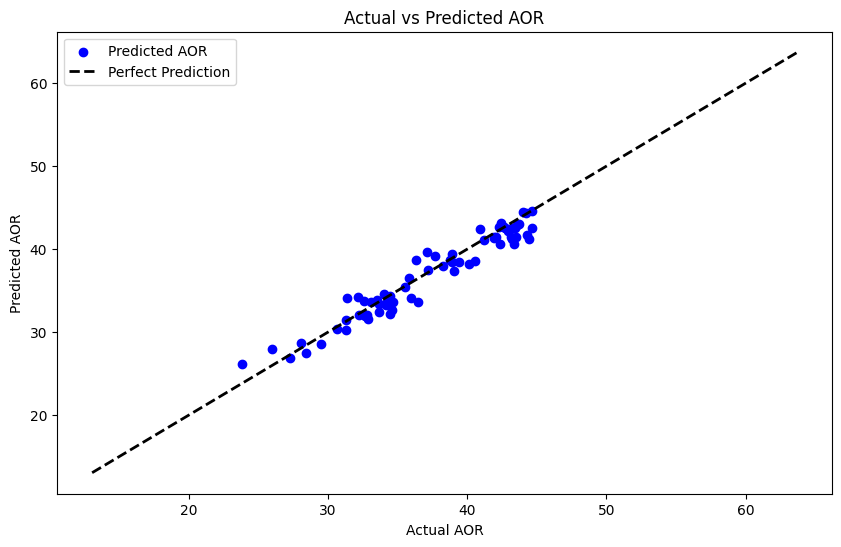

In [86]:
# Plot the actual vs predicted values
plt.figure(figsize=(10,6))
plt.scatter(y_test, y_pred, color='blue', label='Predicted AOR')
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'k--', lw=2, label='Perfect Prediction')
plt.xlabel('Actual AOR')
plt.ylabel('Predicted AOR')
plt.title('Actual vs Predicted AOR')
plt.legend()
plt.show()